In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP
from sklearn.preprocessing import StandardScaler

In [11]:
data = pd.read_csv("../data/city_lifestyle_dataset.csv")

X = data.select_dtypes(include=["float64", "int64"])

In [12]:
data

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [13]:
X = data.drop(columns=["country", "city_name"])

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   population_density      300 non-null    int64  
 1   avg_income              300 non-null    int64  
 2   internet_penetration    300 non-null    float64
 3   avg_rent                300 non-null    int64  
 4   air_quality_index       300 non-null    int64  
 5   public_transport_score  300 non-null    float64
 6   happiness_score         300 non-null    float64
 7   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 18.9 KB


In [15]:
data["country"].unique()

array(['Europe', 'Asia', 'North America', 'South America', 'Africa',
       'Oceania'], dtype=object)

In [16]:
X = StandardScaler().fit_transform(X)

In [17]:
X_umap = UMAP(n_components=2, random_state=42).fit_transform(X)

/home/benk/anaconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Visualisation de la projection UMAP

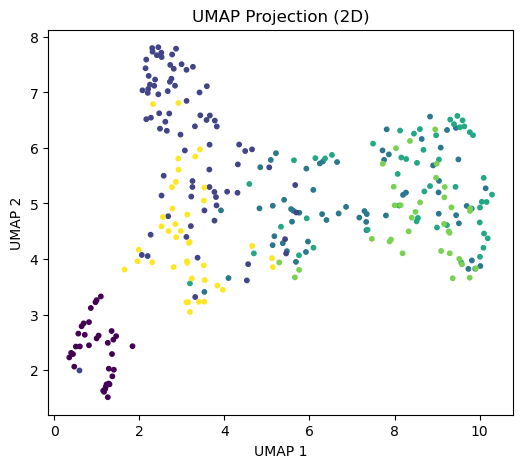

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=data["country"].astype("category").cat.codes,
    s=10
)
plt.title("UMAP Projection (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### Analyse des résultats UMAP

Chaque point représente une ville, colorée selon son pays d'appartenance. On observe une séparation **partielle** entre les différents pays. Le cluster violet en bas à gauche est très bien distinct et isolé du reste, montrant un profil urbain unique. Le cluster bleu en haut présente également une bonne distinction. En revanche, les autres groupes (vert, jaune...) montrent un chevauchement important dans la zone centrale, suggérant que certains pays partagent des caractéristiques de style de vie similaires. La normalisation avec StandardScaler a amélioré la projection, mais révèle que le pays d'appartenance n'est qu'un prédicteur partiel des caractéristiques urbaines.

In [19]:
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df.to_csv("../outputs/umap_emb_2d.csv", index=False)